In [34]:
import cmdstanpy

# CmdStanPy finds CmdStan via the CMDSTAN environment variable (or ~/.cmdstan).
# Set it before launching Jupyter, e.g. `export CMDSTAN=~/cmdstan`.
print("cmdstanpy", cmdstanpy.__version__)
print("cmdstan", ".".join(map(str, cmdstanpy.cmdstan_version())))

cmdstanpy 1.3.0
cmdstan 2.40


# Data construction
Source: Lichess open database, rated standard games, March 2021 (~100M games, https://database.lichess.org/).
The raw PGN (~214 GB decompressed) is not included; it can be rebuilt with:

1. Download and decompress the dump:
   ```
   curl -O https://database.lichess.org/standard/lichess_db_standard_rated_2021-03.pgn.zst
   zstd -d lichess_db_standard_rated_2021-03.pgn.zst
   ```
2. Stream the dump and keep **blitz** games (one rating pool) that open 1.e4 e5 2.Ke2:
   ```
   python3 extract_ratings.py lichess_db_standard_rated_2021-03.pgn lichess_db_bongcloud_2021-03.csv --speed blitz --bongcloud-only
   ```
   → 5,068 games. Cross-check: Lichess's own `[Opening]` tag labels exactly these 5,068 games "Bongcloud Attack".
3. Keep games where Black replied 2...Ke7 (the double bongcloud) → 324 games (done below).

Observational unit: one game. Outcome: Black's blitz rating at the time of the game.
Assumption: games are independent; there are 311 distinct Black players, a few appear 2–3 times.

# Modeling question
## What is the mean Elo of a player reciprocating with the double bongcloud as black?

In [35]:
import numpy as np
import pandas as pd
from cmdstanpy import CmdStanModel
import matplotlib.pyplot as plt
import seaborn as sns

games = pd.read_csv("lichess_db_bongcloud_2021-03.csv")
df = games[games["bke7"] == 1]
df.info()
print(f"{len(games)} games with 1.e4 e5 2.Ke2; {len(df)} with 2...Ke7")
elo = df["black_elo"].to_numpy()

<class 'pandas.core.frame.DataFrame'>
Index: 324 entries, 1 to 5034
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   date       324 non-null    object
 1   white      324 non-null    object
 2   white_elo  324 non-null    int64 
 3   black      324 non-null    object
 4   black_elo  324 non-null    int64 
 5   e4e5       324 non-null    int64 
 6   wke2       324 non-null    int64 
 7   bke7       324 non-null    int64 
 8   opening    324 non-null    object
 9   moves      324 non-null    object
dtypes: int64(5), object(5)
memory usage: 27.8+ KB
5068 games with 1.e4 e5 2.Ke2; 324 with 2...Ke7


# Prior-predictive analysis
## Construct a weak prior

In [36]:
# One model for both prior and posterior predictive runs
model = CmdStanModel(stan_file="stan_code/normal_combined.stan")

# Observed data only; priors and the use_likelihood switch are added per run
lichess_data = {"N": len(elo), "elo": elo.tolist()}

In [37]:
# Quick reference to the data
# mu ~ normal(mu_mean, mu_sd); 
# sigma ~ normal(0, sigma_sd); 
weak_prior = {"mu_mean": 1500, "mu_sd": 1000, "sigma_sd": 1000}
weak_prior_data = {**lichess_data, **weak_prior, "use_likelihood": 0}

fit_weak_prior = model.sample(
    data=weak_prior_data,
    chains=2,
    parallel_chains=2,
    seed=6300,
    show_progress=False
)

print(fit_weak_prior.summary())

y_weak_prior = fit_weak_prior.stan_variable("y_rep")
print("simulated datasets:", y_weak_prior.shape)
print(f"fraction below the 600 floor : {np.mean(y_weak_prior < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(y_weak_prior < 0):.3f}")
print(f"fraction above 3400          : {np.mean(y_weak_prior > 3400):.3f}")

13:42:00 - cmdstanpy - INFO - CmdStan start processing
13:42:00 - cmdstanpy - INFO - Chain [1] start processing
13:42:00 - cmdstanpy - INFO - Chain [2] start processing
13:42:01 - cmdstanpy - INFO - Chain [1] done processing
13:42:01 - cmdstanpy - INFO - Chain [2] done processing


                  Mean       MCSE      StdDev          MAD         5%  \
lp__           5.26277   0.051117     1.10391     0.790019    2.99427   
mu          1453.89000  29.467100   955.88600   987.941000  -64.75740   
sigma        806.01900  19.665500   623.91400   616.689000   45.70490   
y_rep[1]    1430.83000  36.729000  1386.70000  1255.620000 -801.35900   
y_rep[2]    1455.88000  36.055000  1384.47000  1226.260000 -705.88500   
...                ...        ...         ...          ...        ...   
y_rep[320]  1473.42000  35.602700  1379.67000  1287.800000 -764.06300   
y_rep[321]  1462.51000  37.840800  1374.13000  1211.350000 -712.07900   
y_rep[322]  1472.24000  36.629500  1384.97000  1263.510000 -688.42000   
y_rep[323]  1411.12000  40.339300  1431.42000  1250.250000 -867.93700   
y_rep[324]  1405.44000  37.739700  1389.31000  1215.880000 -812.61600   

                   50%         95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__           5.63609     6.35765   586.144

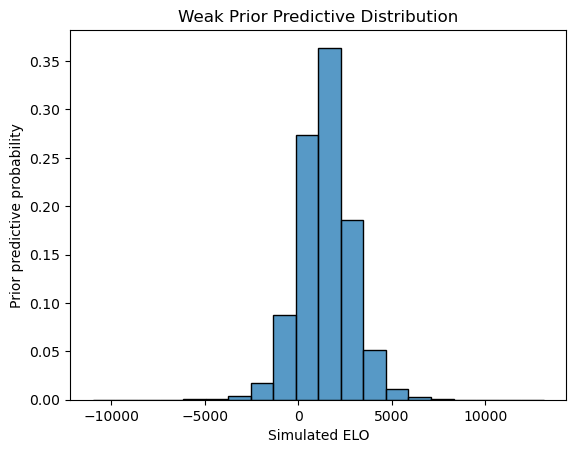

In [38]:
sns.histplot(y_weak_prior.flatten(), bins=20, stat="probability")
plt.xlabel("Simulated ELO")
plt.ylabel("Prior predictive probability")
plt.title("Weak Prior Predictive Distribution")
plt.savefig("figures/weak_prior_predictive.png", dpi=300, bbox_inches="tight")
plt.show()

## Final prior
- $\mu \sim \mathrm{Normal}(1500, 300)$: centered on Lichess's 1500 starting rating; ±600 (2 SD) spans beginner to strong club level.
- $\sigma \sim \mathrm{Normal}^{+}(0, 400)$: Lichess ratings range roughly 600–3000, so a group SD of up to ~800 is plausible.

In [39]:
prior = {"mu_mean": 1500, "mu_sd": 300, "sigma_sd": 400}
prior_data = {**lichess_data, **prior, "use_likelihood": 0}

fit_prior = model.sample(
    data=prior_data,
    chains=2,
    parallel_chains=2,
    seed=6300,
    show_progress=False
)
print(fit_prior.summary())


y_prior = fit_prior.stan_variable("y_rep")
print("simulated datasets:", y_prior.shape)
print(f"fraction below the 600 floor : {np.mean(y_prior < 600):.3f}")
print(f"fraction below 0 (impossible): {np.mean(y_prior < 0):.3f}")
print(f"fraction above 3400          : {np.mean(y_prior > 3400):.3f}")

13:42:03 - cmdstanpy - INFO - CmdStan start processing
13:42:03 - cmdstanpy - INFO - Chain [1] start processing
13:42:03 - cmdstanpy - INFO - Chain [2] start processing
13:42:03 - cmdstanpy - INFO - Chain [1] done processing
13:42:03 - cmdstanpy - INFO - Chain [2] done processing
13:42:03 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.1%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.


                  Mean       MCSE     StdDev         MAD          5%  \
lp__           4.37553   0.052829    1.11373    0.797227     2.31126   
mu          1494.36000  10.284900  291.17500  293.798000  1019.63000   
sigma        324.23100   7.012380  242.61000  234.535000    23.89090   
y_rep[1]    1492.79000  16.339300  521.05400  428.596000   702.20700   
y_rep[2]    1487.47000  14.690800  497.50600  427.333000   708.81100   
...                ...        ...        ...         ...         ...   
y_rep[320]  1495.90000  13.982300  521.52000  419.273000   716.96800   
y_rep[321]  1485.31000  15.012600  475.48700  401.195000   740.36400   
y_rep[322]  1493.82000  13.447500  502.52100  399.676000   710.83500   
y_rep[323]  1492.55000  13.527400  496.32300  404.593000   730.82300   
y_rep[324]  1496.35000  13.898200  486.85700  406.337000   734.63900   

                   50%         95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__           4.69996     5.43349   639.420   556.616  

In [40]:
print(fit_prior.diagnose()) # check for divergences

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
1 of 2000 (0.05%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



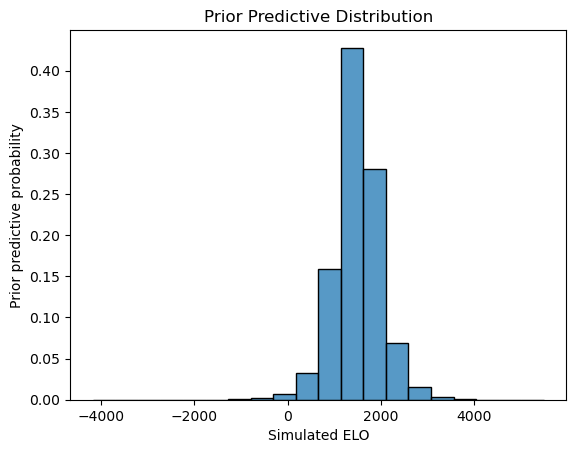

In [41]:
sns.histplot(y_prior.flatten(), bins=20, stat="probability")
plt.xlabel("Simulated ELO")
plt.ylabel("Prior predictive probability")
plt.title("Prior Predictive Distribution")
plt.savefig("figures/prior_predictive.png", dpi=300, bbox_inches="tight")
plt.show()

# Estimation
- Fit the model, with the final choice of prior.
- Show the posterior distribution of every
unknown parameter. Report whether Stan produced warnings.

In [42]:
posterior_data = {**prior_data, "use_likelihood": 1}
estimation_fit = model.sample(
    data=posterior_data,
    chains=4,
    parallel_chains=4,
    seed=6300,
    show_progress=False,
)

print(estimation_fit.summary())
print(estimation_fit.diagnose())

13:42:06 - cmdstanpy - INFO - CmdStan start processing
13:42:06 - cmdstanpy - INFO - Chain [1] start processing
13:42:06 - cmdstanpy - INFO - Chain [2] start processing
13:42:06 - cmdstanpy - INFO - Chain [3] start processing
13:42:06 - cmdstanpy - INFO - Chain [4] start processing
13:42:07 - cmdstanpy - INFO - Chain [1] done processing
13:42:07 - cmdstanpy - INFO - Chain [2] done processing
13:42:07 - cmdstanpy - INFO - Chain [3] done processing
13:42:07 - cmdstanpy - INFO - Chain [4] done processing


                Mean      MCSE     StdDev         MAD        5%       50%  \
lp__       -2065.630  0.024187    1.02438    0.723212 -2067.700 -2065.320   
mu          1314.430  0.377369   20.32580   20.595800  1280.360  1314.740   
sigma        362.646  0.247809   14.45140   14.525500   339.803   362.358   
y_rep[1]    1313.420  5.932950  365.66500  363.584000   711.739  1310.970   
y_rep[2]    1306.770  5.754780  365.57300  365.092000   705.936  1306.950   
...              ...       ...        ...         ...       ...       ...   
y_rep[320]  1310.080  5.720840  362.05700  357.802000   711.985  1308.170   
y_rep[321]  1311.960  6.128660  357.28700  357.919000   719.450  1312.280   
y_rep[322]  1311.370  5.704590  363.71700  353.324000   719.949  1304.390   
y_rep[323]  1316.330  6.000730  371.62000  367.280000   704.409  1315.060   
y_rep[324]  1320.280  6.091030  364.69200  360.048000   715.073  1316.110   

                 95%  ESS_bulk  ESS_tail  ESS_bulk/s     R_hat  
lp__      

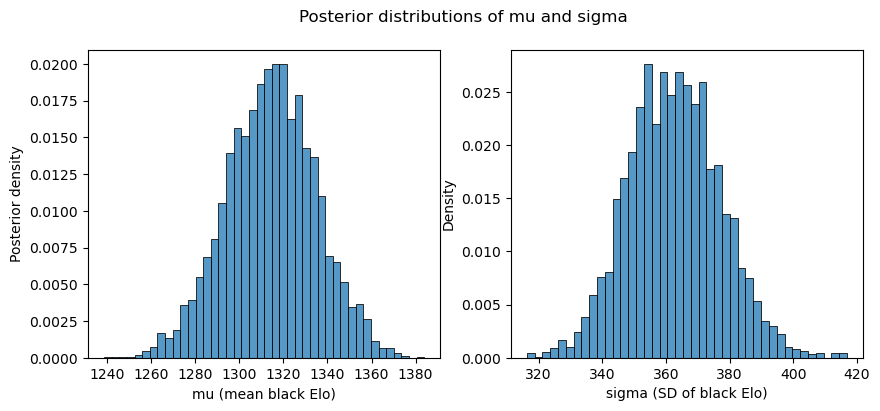

Posterior mean of mu: 1314.43
Posterior mean of sigma: 362.65


In [43]:
mu_draws = estimation_fit.stan_variable("mu")
sigma_draws = estimation_fit.stan_variable("sigma")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(mu_draws, stat="density", ax=axes[0])
axes[0].set_xlabel("mu (mean black Elo)")
sns.histplot(sigma_draws, stat="density", ax=axes[1])
axes[1].set_xlabel("sigma (SD of black Elo)")
axes[0].set_ylabel("Posterior density")
fig.suptitle("Posterior distributions of mu and sigma")
plt.savefig("figures/posterior_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Posterior mean of mu: {mu_draws.mean():.2f}")
print(f"Posterior mean of sigma: {sigma_draws.mean():.2f}")

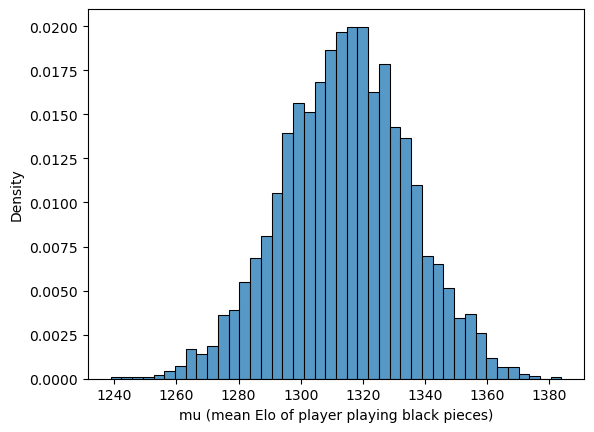

Posterior mean of mu: 1314.43


In [ ]:
# This is for my slide
mu_draws = estimation_fit.stan_variable("mu")
sns.histplot(mu_draws, stat="density")
plt.xlabel("mu (mean Elo of player playing black pieces)")
plt.ylabel("Density")
fig.suptitle("Posterior distributions of mu")
plt.savefig("figures/posterior_mu_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Posterior mean of mu: {mu_draws.mean():.2f}")


### Estimation notes
- **Warnings:** Stan produced no warnings for the posterior fit. `diagnose()` reports no divergences, and satisfactory treedepth, E-BFMI, R-hat and ESS.
- **Posterior:** μ ≈ 1314 (90% interval 1280–1348); σ ≈ 363 (90% interval 340–387).
- **Prior sensitivity:** the earlier prior (μ ~ N(1300, 200), σ ~ N⁺(0, 150)) gave nearly the same posterior (μ ≈ 1314, σ ≈ 359). With N = 324, the data dominate the prior.

# Posterior predictive check
- Use draws from the posterior distribution to simulate replicated datasets.
Compare the observed data with the replicated data using displays or summaries that reveal important
features of the distribution. 
- Explain the most important agreement or disagreement and what it says
about the model. (See Report)

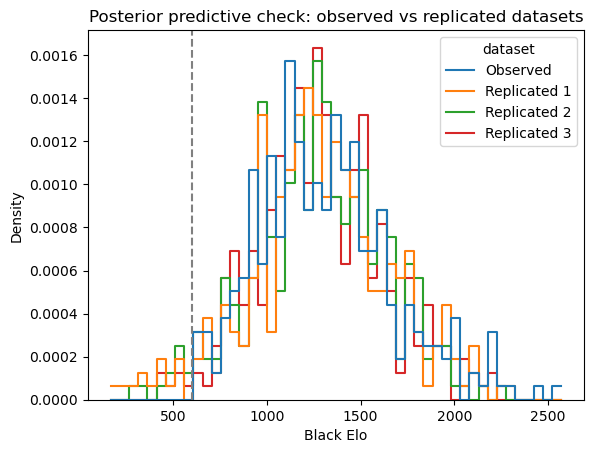

In [44]:
y_posterior = estimation_fit.stan_variable("y_rep")

# Long-form: one row per value, labelled by which dataset it came from
ppc_df = pd.concat(
    [pd.DataFrame({"elo": elo, "dataset": "Observed"})]
    + [pd.DataFrame({"elo": y_posterior[i], "dataset": f"Replicated {i + 1}"})
       for i in range(3)]
)

bins = np.linspace(ppc_df["elo"].min(), ppc_df["elo"].max(), 50)
sns.histplot(data=ppc_df, x="elo", hue="dataset", bins=bins, stat="density",
             common_norm=False, element="step", fill=False)
plt.axvline(600, color="gray", linestyle="--")   # Lichess rating floor
plt.xlabel("Black Elo")
plt.ylabel("Density")
plt.title("Posterior predictive check: observed vs replicated datasets")
plt.savefig("figures/posterior_predictive.png", dpi=300, bbox_inches="tight")
plt.show()

In [45]:
summaries = {
    "mean": (elo.mean(), y_posterior.mean(axis=1)),
    "sd": (elo.std(), y_posterior.std(axis=1)),
    "min": (elo.min(), y_posterior.min(axis=1)),
    "count below 600": ((elo < 600).sum(), (y_posterior < 600).sum(axis=1)),
}
for name, (obs, rep) in summaries.items():
    lo, hi = np.percentile(rep, [5, 95])
    print(f"{name:>16}: observed {obs:8.2f} | replicated 90% range {lo:8.2f} to {hi:8.2f}"
          f" | P(rep >= obs) = {np.mean(rep >= obs):.3f}")

            mean: observed  1313.79 | replicated 90% range  1268.03 to  1361.33 | P(rep >= obs) = 0.521
              sd: observed   360.89 | replicated 90% range   328.99 to   396.65 | P(rep >= obs) = 0.511
             min: observed   611.00 | replicated 90% range    -9.19 to   470.18 | P(rep >= obs) = 0.001
 count below 600: observed     0.00 | replicated 90% range     3.00 to    14.00 | P(rep >= obs) = 1.000
